# Project Title:

# Used Car Price Analysis using Data Collection, Data Cleaning and Exploratory Data Analysis (EDA)

# Phase 1: Problem Statement

# Business Problem Statement

The used car market has thousands of vehicles with different brands, fuel types, transmission types, manufacturing years, and mileage. Buyers often struggle to determine which factors significantly influence the resale price of a used car.

This project aims to analyze the used car market by identifying the key factors affecting car prices and discovering patterns that help customers make informed purchasing decisions and sellers price their vehicles competitively.

The main objective is to analyze the relationship between vehicle features and the final selling price.

# Problem Statement
To analyze used car prices based on different features such as brand, model, year, fuel type, transmission, kilometers driven, and other vehicle attributes to identify factors affecting the final price of cars.

# Target Variable
## Target Feature:

### Final_price

#### Reason:

Final price represents the actual selling price of the used car. By analyzing this variable with other features, we can understand which factors increase or decrease vehicle value.

# Features Description

# Data Collection

# Source 
### Source Website
# Data Source:

### Cars24 Used Cars Website

# Technique Used:

# Import all libraries 

In [1]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# requests

In [2]:
url = "https://www.cars24.com/buy-used-cars-bangalore/?sort=bestmatch&serveWarrantyCount=true&listingSource=TabFilter&storeCityId=4709"

In [3]:
header = {"user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36"}

In [4]:
resp = res.get(url,headers = header)

In [83]:
year = []
brand = []
model = []
varient = []
km_driven = []
fual = []
transmission = []
registration = []
emi_per_month = []
listed_price = []
final_price = []
location = []



city={"bangalore":4709,"hyderabad":3686,"delhi":1,"chennai":5732,"noida":134,"ahmedabad":1632,"jaipur":2130,"mumbai":2378}
brand=["maruti","hyundai","tata","audi","Jeep","BMW","kia","mg","Toyota","skoda"]


for city_name,city_id in city.items():
    for brand_name in brand:

        url=f"https://www.cars24.com/buy-used-{brand_name}-cars-{city_name}/?sort=bestmatch&serveWarrantyCount=true&storeCityId={city_id}"
        
        res=requests.get(url)

        soup=BeautifulSoup(res.text)
        

        # prev code

        for i in soup.find_all("div",class_="styles_contentWrap__9oSrl"):
            ye = re.findall(r"(?<=Stock)\d{4}",i.text)
            if ye:
                year.append(ye[0])
            else:
                year.append(np.nan)
    
            brad = re.findall(r"(Renault|Maruti|Hyundai|Honda|Volkswagen|Tata|Mahindra|MG|Nissan|Chevrolet|Datsun)",i.text)
            if brad:
                brand.append(brad[0])
            else:
                brand.append(np.nan)
                
    
            mode = re.findall(r"(?:Renault|Maruti|Hyundai|Honda|Volkswagen|Tata|Mahindra|MG|Nissan|Chevrolet|Datsun)\s([A-Za-z]+\s+[A-Za-z]+)",i.text)
            if mode:
                model.append(mode[0])
            else:
                model.append(np.nan)
                
    
            var = re.findall(r"(RXT|RXL|ZXI|ZETA|T|VXI|HIGHLINE|LXI|TWIST|SX|W\d+|SHARP|XL|PS)",i.text)
            if var:
                varient.append(var[0])
            else:
                varient.append(np.nan)
            
    
            km = re.findall(r"\d{1,3}(?:,\d{2,3})*(?=\s*km)",i.text)
            if km:
                km_driven.append(km[0])
            else:
                km_driven.append(np.nan)
    
    
            ful = re.findall(r"(Petrol|Diesel|CNG|Electric)",i.text)
            if ful:
                fual.append(ful[0])
            else:
                fual.append(np.nan)
        
            trans = re.findall(r"(Manual|Auto|Automatic)",i.text)
            if trans:
                transmission.append(trans[0])
            else:
                transmission.append(np.nan)
        
            reg = re.findall(r"KA-\d{2}",i.text)
            if reg:
                registration.append(reg[0])
            else:
                registration.append(np.nan)
        
        
            emi = re.findall(r"(?<=₹)\d[\d,]*(?=/m\*)",i.text)
            if emi:
                emi_per_month.append(emi[0])
            else:
                emi_per_month.append(np.nan)
    
    
            listed_pri = re.findall(r"\d+(?:\.\d+)?L",i.text)
            if listed_pri:
                listed_price.append(listed_pri[0])
            else:
                listed_price.append(np.nan)
        
        
            final_pri = re.findall(r"\d+(?:\.\d+)?\s*lakh",i.text)
            if final_pri:
                final_price.append(final_pri[0])
            else:
                final_price.append(np.nan)
        
        
            loc = re.findall(r"(?<=other charges\s).*",i.text)
            if loc:
                location.append(loc[0])
            else:
                location.append(np.nan)
             
            

# Data Frame Creation

## Converted scraped data into Pandas DataFrame.

In [96]:
cars = pd.DataFrame({
    "Year": year, 
    "Brand": 'Brand', 
    "Model": model, 
    "Varient": varient, 
    "KM_Driven": km_driven, 
    "Fual": fual, 
    "Transmission": transmission, 
    "Registration": registration, 
    "EMI/Month": emi_per_month, 
    "Listed_price": listed_price, 
    "Final_price": final_price, 
    "Location": location
})

In [98]:
cars

,Year,Brand,Model,Varient,KM_Driven,Fual,Transmission,Registration,EMI/Month,Listed_price,Final_price,Location
0,2020,maruti,Swift VXI,VXI,"23,582",Petrol,Manual,KA-03,"9,691",5.67L,5.49 lakh,"Whitefield Main Road, Bhoruka Tech Park, Benga..."
1,2017,hyundai,Baleno ZETA,ZETA,"261,040",Petrol,Manual,KA-03,"9,291",5.36L,4.75 lakh,"GT World Mall, Bengaluru"
2,2015,tata,Swift LXI,LXI,"1,13,654",Petrol,Manual,KA-22,"8,558",3.79L,3.25 lakh,"Bellahalli, Bengaluru"
3,2023,audi,Baleno ALPHA,T,"250,479",Petrol,Manual,KA-65,"12,886",7.50L,7.30 lakh,"Whitefield Main Road, Bhoruka Tech Park, Benga..."
4,2013,Jeep,Alto K,VXI,"98,293",Petrol,Manual,KA-13,"8,097",2.28L,1.72 lakh,"Bellahalli, Bengaluru"
...,...,...,...,...,...,...,...,...,...,...,...,...
982,NaN,NaN,NaN,T,"73,382",Petrol,Auto,NaN,"4,977",NaN,1.89 lakh,NaN
983,NaN,NaN,NaN,T,"59,066",Petrol,Manual,NaN,"15,104",NaN,1.70 lakh,NaN
984,NaN,NaN,NaN,T,"1,01,599",Diesel,Manual,NaN,NaN,NaN,1.20 lakh,NaN
985,NaN,NaN,NaN,T,"1,13,741",Diesel,Manual,NaN,NaN,NaN,2.27 lakh,NaN


In [99]:
cars.shape

(987, 12)

# Export Data

### Save dataset into CSV format

In [102]:
cars.to_csv("project_data_set_r_v.csv",index = False)

# Data Loading
### Read CSV file:

In [6]:
cars24 = pd.read_csv("project_data_set_r_v.csv")
cars24

,Year,Brand,Model,Varient,KM_Driven,Fual,Transmission,Registration,EMI/Month,Listed_price,Final_price,Location
0,2020.0,maruti,Swift VXI,VXI,"23,582",Petrol,Manual,KA-03,"9,691",5.67L,5.49 lakh,"Whitefield Main Road, Bhoruka Tech Park, Benga..."
1,2017.0,hyundai,Baleno ZETA,ZETA,"261,040",Petrol,Manual,KA-03,"9,291",5.36L,4.75 lakh,"GT World Mall, Bengaluru"
2,2015.0,tata,Swift LXI,LXI,"1,13,654",Petrol,Manual,KA-22,"8,558",3.79L,3.25 lakh,"Bellahalli, Bengaluru"
3,2023.0,audi,Baleno ALPHA,T,"250,479",Petrol,Manual,KA-65,"12,886",7.50L,7.30 lakh,"Whitefield Main Road, Bhoruka Tech Park, Benga..."
4,2013.0,Jeep,Alto K,VXI,"98,293",Petrol,Manual,KA-13,"8,097",2.28L,1.72 lakh,"Bellahalli, Bengaluru"
...,...,...,...,...,...,...,...,...,...,...,...,...
982,NaN,NaN,NaN,T,"73,382",Petrol,Auto,NaN,"4,977",NaN,1.89 lakh,NaN
983,NaN,NaN,NaN,T,"59,066",Petrol,Manual,NaN,"15,104",NaN,1.70 lakh,NaN
984,NaN,NaN,NaN,T,"1,01,599",Diesel,Manual,NaN,NaN,NaN,1.20 lakh,NaN
985,NaN,NaN,NaN,T,"1,13,741",Diesel,Manual,NaN,NaN,NaN,2.27 lakh,NaN


In [8]:
cars24.duplicated().sum()

np.int64(0)

# Data Understanding

# Shape

### Number of Rows:

In [175]:
df.shape

(987, 12)

# Columns

In [176]:
df.columns

Index(['Year', 'Brand', 'Model', 'Varient', 'KM_Driven', 'Fual',
       'Transmission', 'Registration', 'EMI/Month', 'Listed_price',
       'Final_price', 'Location'],
      dtype='object')

#  Data Types

In [177]:
df.dtypes

Year            float64
Brand            object
Model            object
Varient          object
KM_Driven        object
Fual             object
Transmission     object
Registration     object
EMI/Month        object
Listed_price     object
Final_price      object
Location         object
dtype: object

# head()

In [178]:
df.head()

,Year,Brand,Model,Varient,KM_Driven,Fual,Transmission,Registration,EMI/Month,Listed_price,Final_price,Location
0,2020.0,maruti,Swift VXI,VXI,"23,582",Petrol,Manual,KA-03,"9,691",5.67L,5.49 lakh,"Whitefield Main Road, Bhoruka Tech Park, Benga..."
1,2017.0,hyundai,Baleno ZETA,ZETA,"261,040",Petrol,Manual,KA-03,"9,291",5.36L,4.75 lakh,"GT World Mall, Bengaluru"
2,2015.0,tata,Swift LXI,LXI,"1,13,654",Petrol,Manual,KA-22,"8,558",3.79L,3.25 lakh,"Bellahalli, Bengaluru"
3,2023.0,audi,Baleno ALPHA,T,"250,479",Petrol,Manual,KA-65,"12,886",7.50L,7.30 lakh,"Whitefield Main Road, Bhoruka Tech Park, Benga..."
4,2013.0,Jeep,Alto K,VXI,"98,293",Petrol,Manual,KA-13,"8,097",2.28L,1.72 lakh,"Bellahalli, Bengaluru"


# tail()

In [179]:
df.tail()

,Year,Brand,Model,Varient,KM_Driven,Fual,Transmission,Registration,EMI/Month,Listed_price,Final_price,Location
982,NaN,NaN,NaN,T,"73,382",Petrol,Auto,NaN,"4,977",NaN,1.89 lakh,NaN
983,NaN,NaN,NaN,T,"59,066",Petrol,Manual,NaN,"15,104",NaN,1.70 lakh,NaN
984,NaN,NaN,NaN,T,"1,01,599",Diesel,Manual,NaN,NaN,NaN,1.20 lakh,NaN
985,NaN,NaN,NaN,T,"1,13,741",Diesel,Manual,NaN,NaN,NaN,2.27 lakh,NaN
986,NaN,NaN,NaN,T,"49,017",Petrol,Auto,NaN,"8,739",NaN,4.47 lakh,NaN


# Dataset Information (info)

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 987 entries, 0 to 986
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          784 non-null    float64
 1   Brand         640 non-null    object 
 2   Model         606 non-null    object 
 3   Varient       957 non-null    object 
 4   KM_Driven     987 non-null    object 
 5   Fual          987 non-null    object 
 6   Transmission  987 non-null    object 
 7   Registration  125 non-null    object 
 8   EMI/Month     946 non-null    object 
 9   Listed_price  716 non-null    object 
 10  Final_price   987 non-null    object 
 11  Location      685 non-null    object 
dtypes: float64(1), object(11)
memory usage: 92.7+ KB


# Statistical Summary

In [181]:
df.describe()

,Year
count,784.000000
mean,2019.880102
std,2.911362
min,2012.000000
25%,2018.000000
50%,2020.000000
75%,2022.000000
max,2026.000000


The describe() function summarizes the numerical features by calculating count, mean, standard deviation, minimum, maximum, and quartile values. These statistics provide an overview of the distribution and spread of numerical variables.

# Missing Values

In [182]:
df.isna().sum()

Year            203
Brand           347
Model           381
Varient          30
KM_Driven         0
Fual              0
Transmission      0
Registration    862
EMI/Month        41
Listed_price    271
Final_price       0
Location        302
dtype: int64

# Duplicate Records

In [183]:
df.duplicated().sum()

np.int64(0)

Duplicate records are identified to ensure that each row represents a unique used car listing. Removing duplicates improves data quality and prevents biased analysis.

# Data Cleaning

1. Year
2. Brand
3. Model
4. Varient
5. KM_Driven
6. Fual (rename to Fuel if appropriate)
7. Transmission
8. Registration
9. EMI/Month
10. Listed_price
11. Final_price
12. Location

In [184]:
df.isna().sum()

Year            203
Brand           347
Model           381
Varient          30
KM_Driven         0
Fual              0
Transmission      0
Registration    862
EMI/Month        41
Listed_price    271
Final_price       0
Location        302
dtype: int64

## Fill Year using Brand and Model

In [5]:
df['Year'].fillna(df['Year'].median(), inplace = True)

# Since Year is numerical and represents manufacturing year, use the median.

## Fill Brand using Brand and Model

In [6]:
df["Brand"].fillna(df["Brand"].mode()[0], inplace = True)

# Missing values in the Brand column were replaced with the most frequently occurring brand (mode).

## Fill Model using Brand and Model

In [7]:
df["Model"].fillna(
    df.groupby("Brand")["Model"].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'Not Defined'),inplace = True)

# 

## Fill Varient using Brand and Model

In [8]:
df["Varient"].fillna(
    df.groupby(["Brand", "Model"])["Varient"].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'not defined'), inplace = True)

# Missing values in the Varient column were filled using the most common variant for each Brand-Model combination.

## Fill Varient using Brand and Model

In [9]:
df["Registration"].value_counts()  #  the columns having more than 70 percentage of nulls thats why we remove that column

df = df.drop("Registration", axis=1)



# The Registration column contains approximately 87% missing values, which is more than the acceptable threshold of 70%. Since most of the data is missing, filling these values would not be reliable and could affect the analysis. Therefore, the Registration column was removed to improve the quality of the dataset.

## Fill Varient using Brand and Model

In [10]:
# 1. Remove any commas and convert the column to a numeric type (float)
df['EMI/Month'] = df['EMI/Month'].astype(str).str.replace(",", "").astype(float)

# 2. Fill missing values using the mean of the respective Brand and Model
df["EMI/Month"].fillna(
    df.groupby(["Brand", "Model"])["EMI/Month"].transform("mean"), 
    inplace=True
)

# Missing EMI values were filled using the median EMI for each Brand-Model group, with any remaining missing values replaced by the overall median.

## Listed_price fill with Brand

In [11]:
df["Listed_price"] = df["Listed_price"].str.replace("L", "", regex=False)   # The character 'L' (representing lakh) was removed so that the column can be converted into a numeric data type.

df["Listed_price"] = df["Listed_price"].astype(float)   #  The Listed_price column was converted from object to float64, making it suitable for numerical calculations and visualization.

df["Listed_price"].fillna(
    df.groupby("Brand")["Listed_price"].transform("mean"), inplace = True)


# Missing values in Listed_price were filled using the median listed price of the corresponding Brand. Any remaining missing values were replaced with the overall mean, preserving the distribution of prices.

## Location fill with unknown

In [12]:
df["Location"] = df["Location"].fillna("User Not Defined")

# The missing values in the Location column were replaced with "User Not Defined" because the actual location information was unavailable. This ensures that all records are retained while clearly identifying missing location details.

# convert Data Types

### Convert Year:

In [13]:
df['Year'] = df['Year'].astype(int)

### Convert Model

In [14]:
df["Model"] = df["Model"].str.replace(r"\s+", " ", regex=True).str.strip()

### Convert KM_Driven

In [15]:
df["KM_Driven"] = (df["KM_Driven"]
      .str.replace(",", "")
      .str.replace(" km", "")
      .astype(int))

### Rename fual into Fuel

In [16]:
df.rename(columns={"Fual":"Fuel"}, inplace=True)

### convert EMI/MONTH float into int

In [17]:
df['EMI/Month'] = df['EMI/Month'].astype(int)

### Replace Lakh into space

In [18]:
df["Final_price"] = (df["Final_price"]
      .str.extract(r"(\d+\.\d+)")
      .astype(float))

### Reanme the columns

In [24]:
df.rename(columns={"Listed_price_Lakh's":"Listed_price_Lakh"}, inplace=True)
df.rename(columns={"Final_price_Lakh's":"Final_price_Lakh"}, inplace=True)

## Check the dataframe is clean or not

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 987 entries, 0 to 986
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               987 non-null    int64  
 1   Brand              987 non-null    object 
 2   Model              987 non-null    object 
 3   Varient            987 non-null    object 
 4   KM_Driven          987 non-null    int64  
 5   Fuel               987 non-null    object 
 6   Transmission       987 non-null    object 
 7   EMI/Month          987 non-null    int64  
 8   Listed_price_Lakh  987 non-null    float64
 9   Final_price        987 non-null    float64
 10  Location           987 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 84.9+ KB


## Recheck any Null's present in the dataframe

In [21]:
df.isnull().sum()

Year                   0
Brand                  0
Model                  0
Varient                0
KM_Driven              0
Fuel                   0
Transmission           0
EMI/Month              0
Listed_price_Lakh's    2
Final_price            0
Location               0
dtype: int64

## To save clean dataframe

In [28]:
df.to_csv("cars24_clean_data_project1.csv", index = False)

# now the data set is clean and next we go to analysys 

## load clean dataset

In [10]:
df = pd.read_csv("cars24_clean_data_project1.csv")

# Exploratory Data Analysis (EDA)

In [11]:
df.describe()

,Year,KM_Driven,EMI/Month,Listed_price_Lakh,Final_price
count,987.000000,9.870000e+02,987.000000,987.000000,987.000000
mean,2019.904762,1.017680e+05,15030.366768,6.776976,7.080344
std,2.594863,2.806221e+05,9964.102032,3.652916,3.703020
min,2012.000000,2.203000e+03,2633.000000,1.000000,0.850000
25%,2019.000000,4.146300e+04,8862.500000,4.400000,4.075000
50%,2020.000000,6.392500e+04,13518.000000,6.970027,6.840000
75%,2022.000000,9.147300e+04,17859.000000,8.005000,9.190000
max,2026.000000,5.148756e+06,108709.000000,34.080000,30.260000


In [12]:
df.groupby('Brand')['KM_Driven'].agg(['mean', 'median'])

,mean,median
Brand,,
BMW,63411.000000,63411.0
Hyundai,111306.552268,63756.0
Jeep,98293.000000,98293.0
MG,58224.980000,52533.0
Maruti,106105.418750,68014.0
Tata,108040.681250,71897.5
Toyota,79810.000000,79810.0
audi,250479.000000,250479.0
hyundai,261040.000000,261040.0


# Detecting and Handling Outliers using Iqr Method

## Handling Outliers in Final Price

<Axes: >

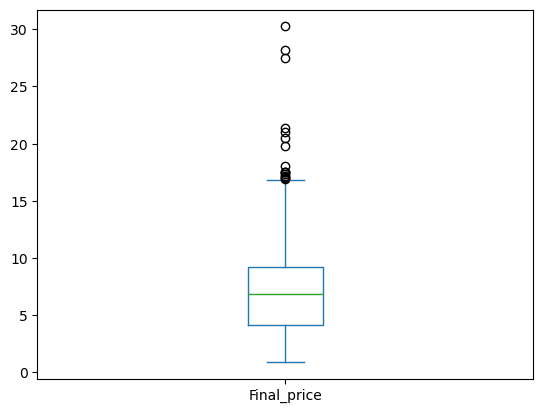

In [13]:
#df.info()
df['Final_price'].plot(kind = 'box')  # clip

In [14]:
q1 = df['Final_price'].quantile(0.25)
q3 = df['Final_price'].quantile(0.75)
iqr=q3-q1

lower=q1-1.5*iqr
upper=q3+1.5*iqr
df['Final_price']=df['Final_price'].clip(lower,upper)

<Axes: >

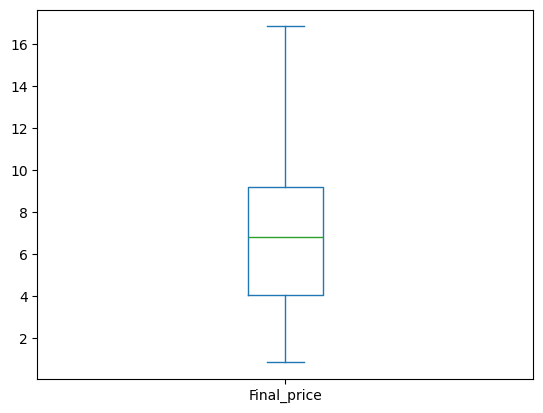

In [15]:
df['Final_price'].plot(kind = 'box')


## Handling Outliers in Final Price

<Axes: >

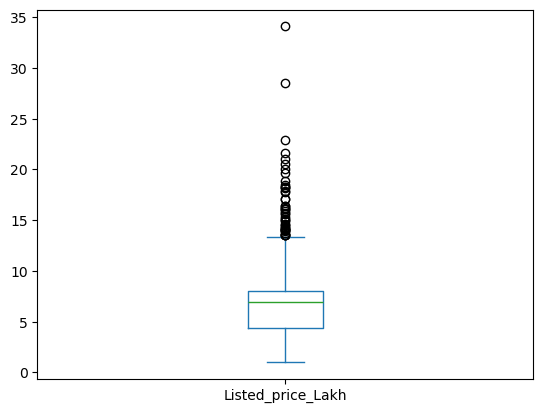

In [16]:
df['Listed_price_Lakh'].plot(kind = 'box')


In [17]:
q1 = df['Listed_price_Lakh'].quantile(0.25)
q3 = df['Listed_price_Lakh'].quantile(0.75)
iqr=q3-q1

lower=q1-1.5*iqr
upper=q3+1.5*iqr
df['Listed_price_Lakh']=df['Listed_price_Lakh'].clip(lower,upper)

<Axes: >

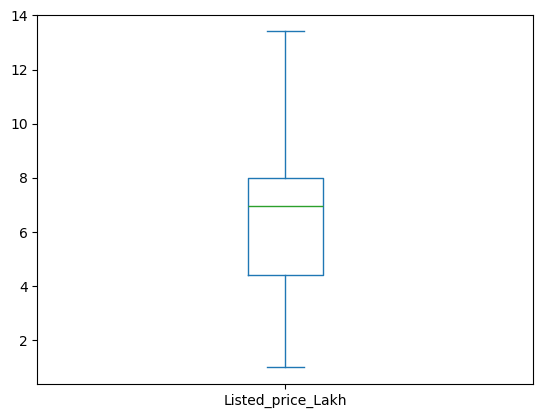

In [18]:
df['Listed_price_Lakh'].plot(kind = 'box')


<Axes: >

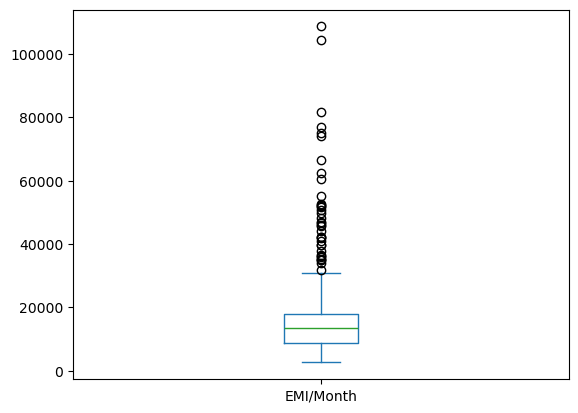

In [19]:
df['EMI/Month'].plot(kind = 'box')


In [20]:
q1 = df['EMI/Month'].quantile(0.25)
q3 = df['EMI/Month'].quantile(0.75)
iqr=q3-q1

lower=q1-1.5*iqr
upper=q3+1.5*iqr
df['EMI/Month']=df['EMI/Month'].clip(lower,upper)

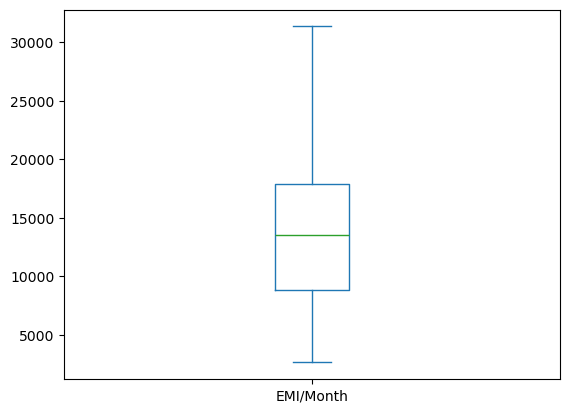

In [21]:
df['EMI/Month'].plot(kind = 'box')
plt.show()

<Axes: >

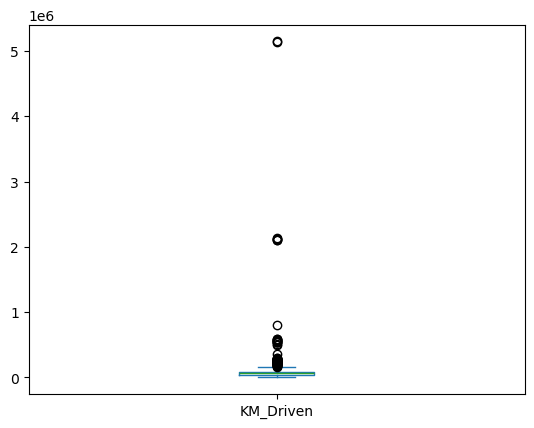

In [22]:
df['KM_Driven'].plot(kind = "box")

In [23]:
q1 = df['KM_Driven'].quantile(0.25)
q3 = df['KM_Driven'].quantile(0.75)
iqr=q3-q1

lower=q1-1.5*iqr
upper=q3+1.5*iqr
df['KM_Driven']=df['KM_Driven'].clip(lower,upper)

<Axes: >

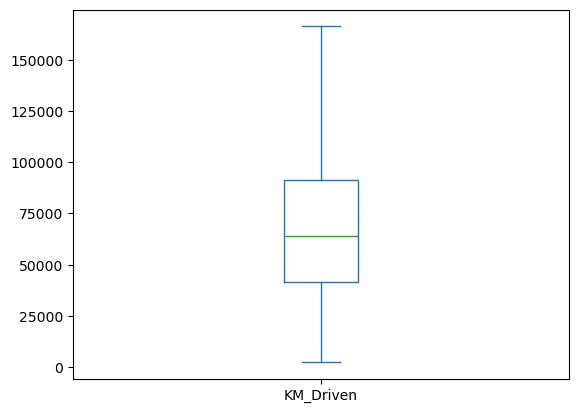

In [24]:
df['KM_Driven'].plot(kind = "box")

In [28]:
df.sort_values(by = 'Year', ascending = False)

,Year,Brand,Model,Varient,KM_Driven,Fuel,Transmission,EMI/Month,Listed_price_Lakh,Final_price,Location
912,2026,Tata,PUNCH Accomplished,T,2926,Petrol,Auto,14640.00,8.8900,8.55,"Korum Mall, Thane West"
315,2025,Tata,PUNCH Creative,T,7358,Petrol,Manual,13806.00,9.2200,8.06,User Not Defined
56,2025,Tata,Tiago XZ,T,6912,CNG,Manual,11739.00,8.5200,6.65,"Bellahalli, Bengaluru"
941,2025,Hyundai,HECTOR SHARP,T,2759,Petrol,Auto,18492.00,13.4125,10.80,"Regency Anantam, Dombivli East"
681,2025,Tata,ALTROZ XMA,T,7665,Petrol,Manual,13326.00,8.5100,7.55,"Naroda, Ahmedabad"
...,...,...,...,...,...,...,...,...,...,...,...
4,2013,Jeep,Alto K,VXI,98293,Petrol,Manual,8097.00,2.2800,1.72,"Bellahalli, Bengaluru"
276,2013,Maruti,Swift VDI,T,90372,Diesel,Manual,31353.75,4.2100,3.59,User Not Defined
124,2013,Hyundai,Swift ZXI,ZXI,93503,Petrol,Manual,14357.00,3.4700,3.05,"Kompally, Hyderabad"
298,2012,Hyundai,HECTOR SHARP,T,37651,Petrol,Auto,26382.00,3.0200,2.97,User Not Defined


In [29]:
df.groupby(['Brand','Model'])['Final_price'].agg(['mean', 'median'])

mean  median
Brand   Model                    
BMW     Alto K       2.89    2.89
Hyundai ALTROZ XE    3.80    3.80
        ALTROZ XT    4.32    4.32
        ALTROZ XZ    4.33    4.33
        ASTOR SAVVY  7.80    7.80
...                   ...     ...
kia     Not Defined  2.70    2.70
maruti  Swift VXI    5.49    5.49
mg      Alto K       2.25    2.25
skoda   Alto K       4.19    4.19
tata    Swift LXI    3.25    3.25

[182 rows x 2 columns]

In [30]:
df[['Brand','Model']].value_counts()

Brand    Model        
Hyundai  HECTOR SHARP     269
MG       HECTOR SHARP      95
Tata     NEXON XZ          85
Maruti   Grand i           31
Hyundai  Grand i           25
                         ... 
         Windsor EV         1
         Vitara Brezza      1
         Verna SX           1
         Tiago XTA          1
tata     Swift LXI          1
Name: count, Length: 182, dtype: int64

In [31]:
df['Model'].value_counts()

Model
HECTOR SHARP        364
NEXON XZ             98
Grand i              56
HECTOR PLUS          28
Creta SX             28
                   ... 
Harrier FEARLESS      1
NEXON XE              1
Safari XZ             1
Tiago WIZZ            1
ASTOR Shine           1
Name: count, Length: 116, dtype: int64

In [32]:
df.groupby('Brand')['Final_price'].max().sort_values(ascending=False)

Brand
Hyundai    16.8625
MG         16.8625
Tata       16.8625
Maruti      9.8200
audi        7.3000
maruti      5.4900
hyundai     4.7500
Toyota      4.4000
skoda       4.1900
tata        3.2500
BMW         2.8900
kia         2.7000
mg          2.2500
Jeep        1.7200
Name: Final_price, dtype: float64

In [33]:
df.groupby('Brand')['Final_price'].min().sort_values(ascending=True)

Brand
MG         0.85
Hyundai    0.90
Maruti     0.99
Tata       1.01
Jeep       1.72
mg         2.25
kia        2.70
BMW        2.89
tata       3.25
skoda      4.19
Toyota     4.40
hyundai    4.75
maruti     5.49
audi       7.30
Name: Final_price, dtype: float64

In [34]:
df.groupby('Brand')['KM_Driven'].min().sort_values(ascending=False)

Brand
audi       166488
hyundai    166488
tata       113654
Jeep        98293
Toyota      79810
BMW         63411
mg          57802
kia         38572
skoda       28810
maruti      23582
Maruti      11403
MG           3910
Tata         2926
Hyundai      2203
Name: KM_Driven, dtype: int64

In [35]:
df.groupby('Brand')['EMI/Month'].max().sort_values(ascending=False)

Brand
Hyundai    31353.75
MG         31353.75
Maruti     31353.75
Tata       31353.75
audi       12886.00
Toyota     11587.00
maruti      9691.00
hyundai     9291.00
tata        8558.00
Jeep        8097.00
skoda       7396.00
BMW         6431.00
mg          5925.00
kia         5282.00
Name: EMI/Month, dtype: float64

# Data Visualization

# Univariate Analysis

# Year Distribution

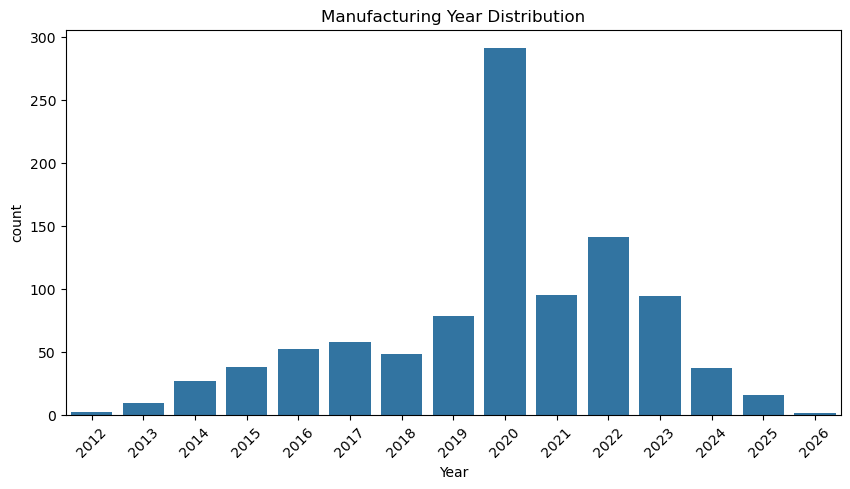

In [67]:
plt.figure(figsize=(10,5))
sns.countplot(x='Year', data=df)
plt.xticks(rotation=45)
plt.title("Manufacturing Year Distribution")
plt.show()

# Count Plot (Fuel)



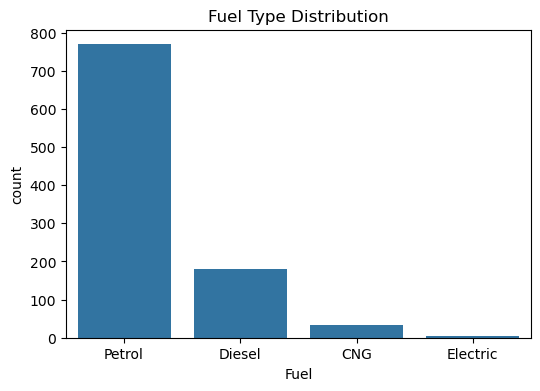

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(x='Fuel', data=df)
plt.title("Fuel Type Distribution")
plt.show()

##  Brand Analysis

In [20]:
# Count of cars by brand
brand_count = df['Brand'].value_counts()
print(brand_count)


# value_counts() counts the occurrences of each brand.
# It helps identify the most and least common brands in the dataset.

Brand
Hyundai    507
Maruti     160
Tata       160
MG         150
maruti       1
hyundai      1
tata         1
audi         1
Jeep         1
BMW          1
kia          1
mg           1
Toyota       1
skoda        1
Name: count, dtype: int64


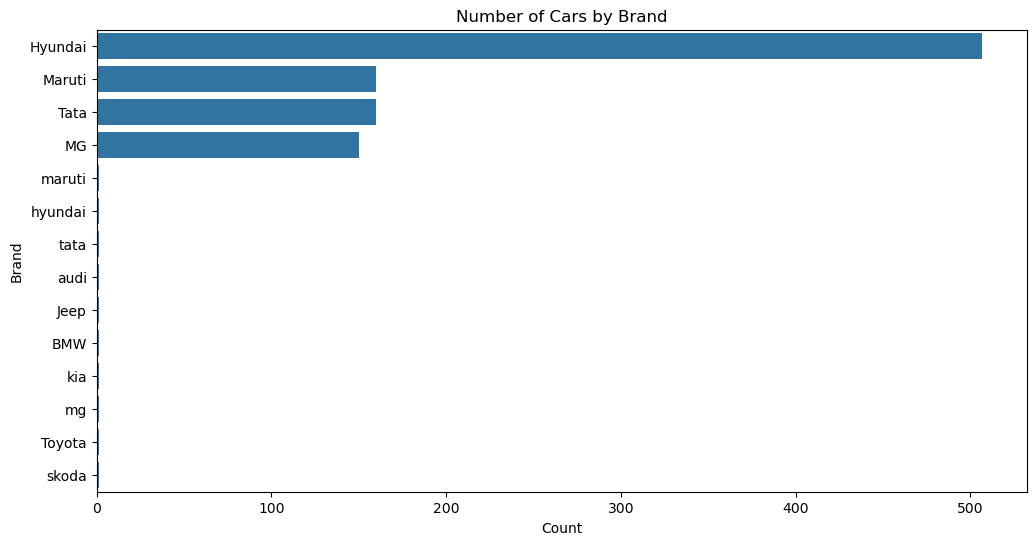

In [42]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, y='Brand', order = df['Brand'].value_counts().index)

plt.title("Number of Cars by Brand")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()

#  Distribution of KM Driven

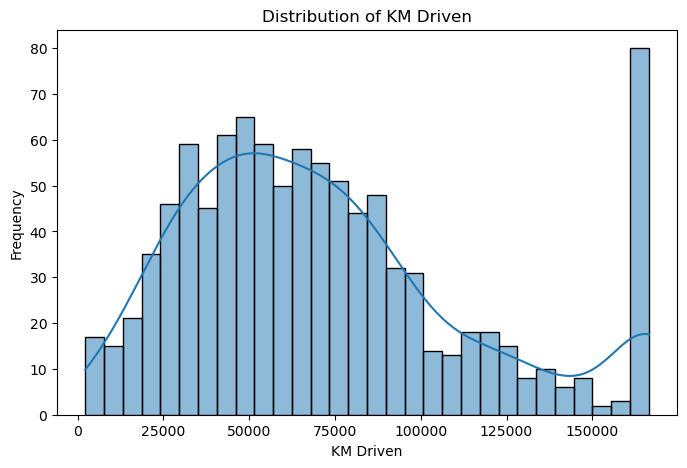

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['KM_Driven'], bins=30, kde=True)
plt.title("Distribution of KM Driven")
plt.xlabel("KM Driven")
plt.ylabel("Frequency")
plt.show()

#  Histogram (Final Price)

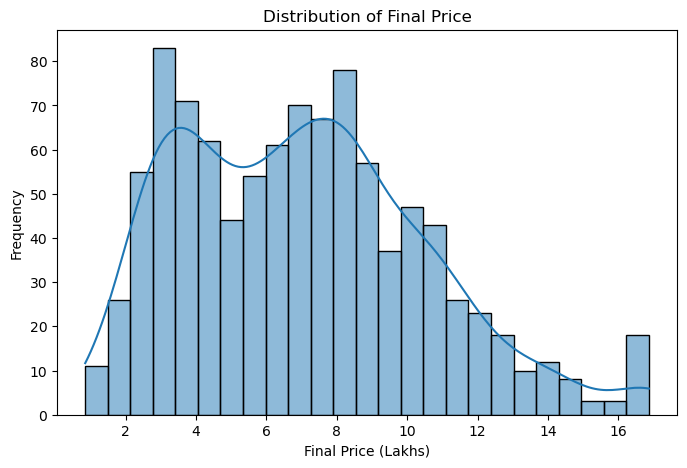

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['Final_price'], bins=25, kde=True)
plt.title("Distribution of Final Price")
plt.xlabel("Final Price (Lakhs)")
plt.ylabel("Frequency")
plt.show()

Interpretation

--> Most cars are priced at the lower end.
--> A few luxury vehicles have much higher prices.
--> The distribution is positively skewed (right-skewed).

Business Insight

--> The majority of Cars24 listings are budget and mid-range vehicles, while premium cars are available in smaller numbers.

# Bi Variate Analysis

# KM Driven vs Final Price

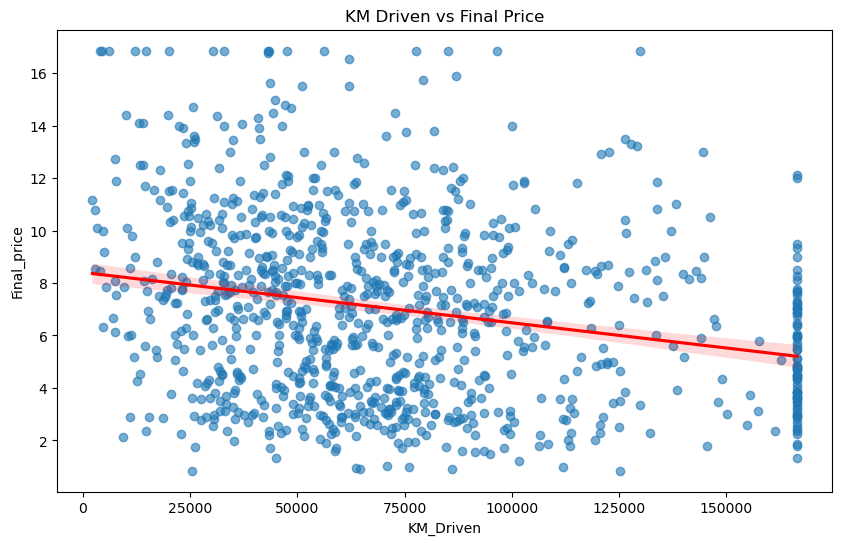

In [75]:
plt.figure(figsize=(10,6))
sns.regplot(
    x='KM_Driven',
    y='Final_price',
    data=df,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)
plt.title("KM Driven vs Final Price")
plt.show()

#  Violin Plot

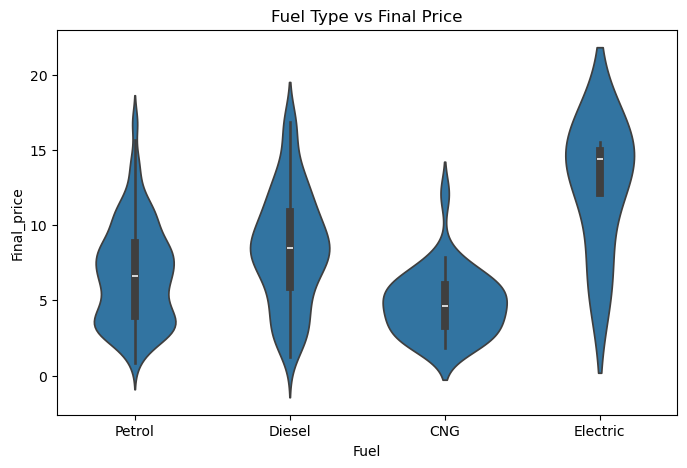

In [47]:
plt.figure(figsize=(8,5))
sns.violinplot(x=df['Fuel'], y=df['Final_price'])
plt.title("Fuel Type vs Final Price")
plt.show()

#  Pie Chart (Transmission)

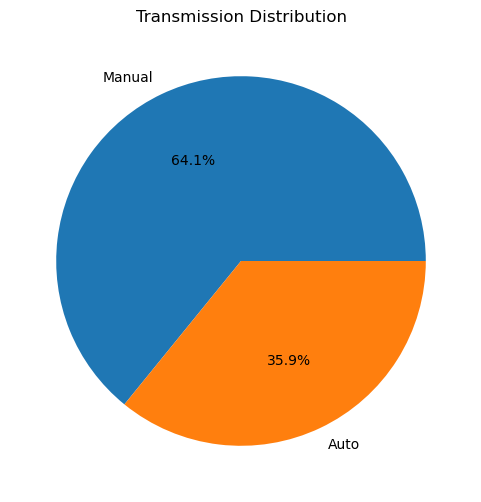

In [50]:
df['Transmission'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title("Transmission Distribution")
plt.ylabel("")
plt.show()

Interpretation

Transmission	Percentage
Manual	64.1%
Automatic	35.9%

--> Nearly three-fourths of the listed cars have Manual transmission.
--> Around one-fourth have Automatic transmission.

Business Insight

The pie chart indicates that Manual transmission vehicles account for the majority of used car listings, while Automatic transmission vehicles represent a smaller share. This suggests that the used car market is still largely dominated by manual vehicles, reflecting their wider availability and popularity.

#  Bar Plot (Average Price by Brand)

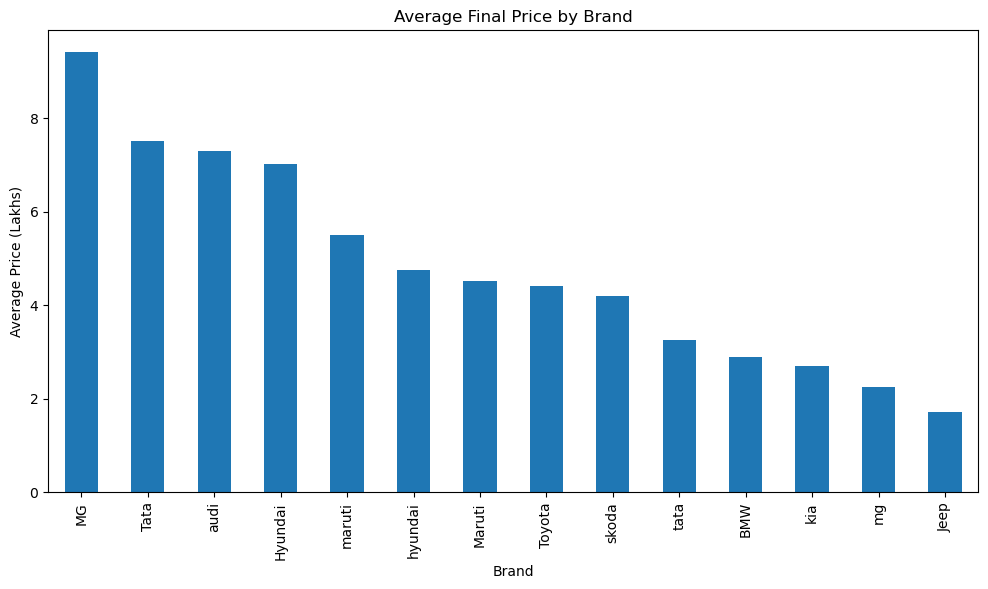

In [53]:
brand_price = df.groupby('Brand')['Final_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
brand_price.plot(kind='bar')
plt.title("Average Final Price by Brand")
plt.ylabel("Average Price (Lakhs)")
plt.show()

Interpretation

The graph compares the average final selling price of used cars across different brands. Among the listed brands, MG has the highest average final price, followed by Tata, Audi, and Hyundai. Brands such as Jeep, MG (lowercase), and Kia show comparatively lower average prices. However, the graph also reveals inconsistent brand names (e.g., MG and mg, Tata and tata, Hyundai and hyundai), indicating that the Brand column requires standardization before drawing final business conclusions.

Business Insight (After Cleaning)

After standardizing the brand names, premium brands such as Audi and MG are expected to have higher average resale prices, while mass-market brands like Maruti, Hyundai, and Tata typically occupy the mid-range price segment. Brand reputation and vehicle segment significantly influence the resale value of used cars.

#  Scatter Plot (KM Driven vs Final Price)

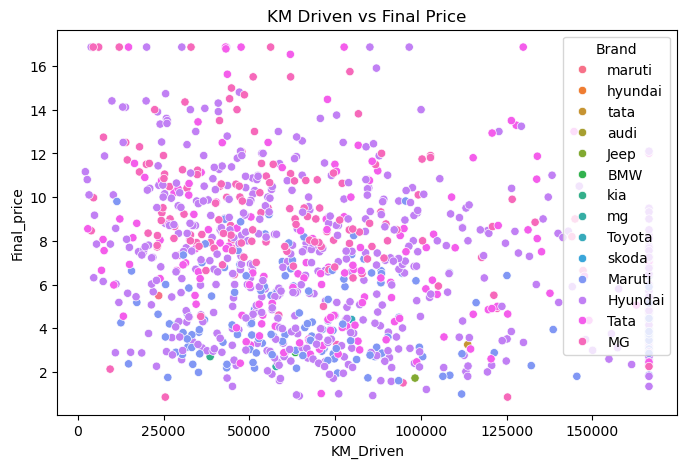

In [56]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='KM_Driven', y='Final_price', data=df, hue = 'Brand')
plt.title("KM Driven vs Final Price")
plt.show()

#  Scatter Plot (Year vs Final Price)

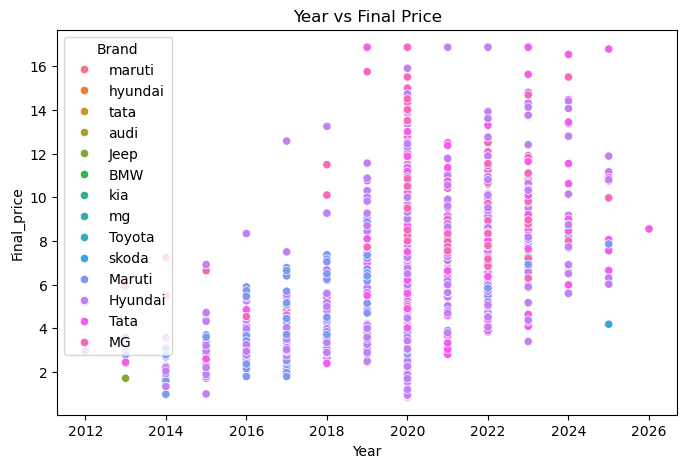

In [61]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Year', y='Final_price', data=df, hue = 'Brand')
plt.title("Year vs Final Price")
plt.show()


# Multivariate Analysis

# Correlation Heatmap

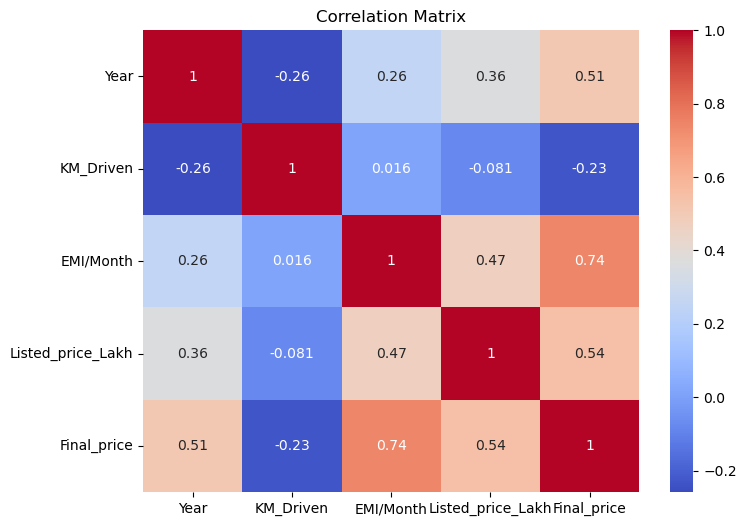

In [77]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Year','KM_Driven','EMI/Month','Listed_price_Lakh','Final_price']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# Pairplot

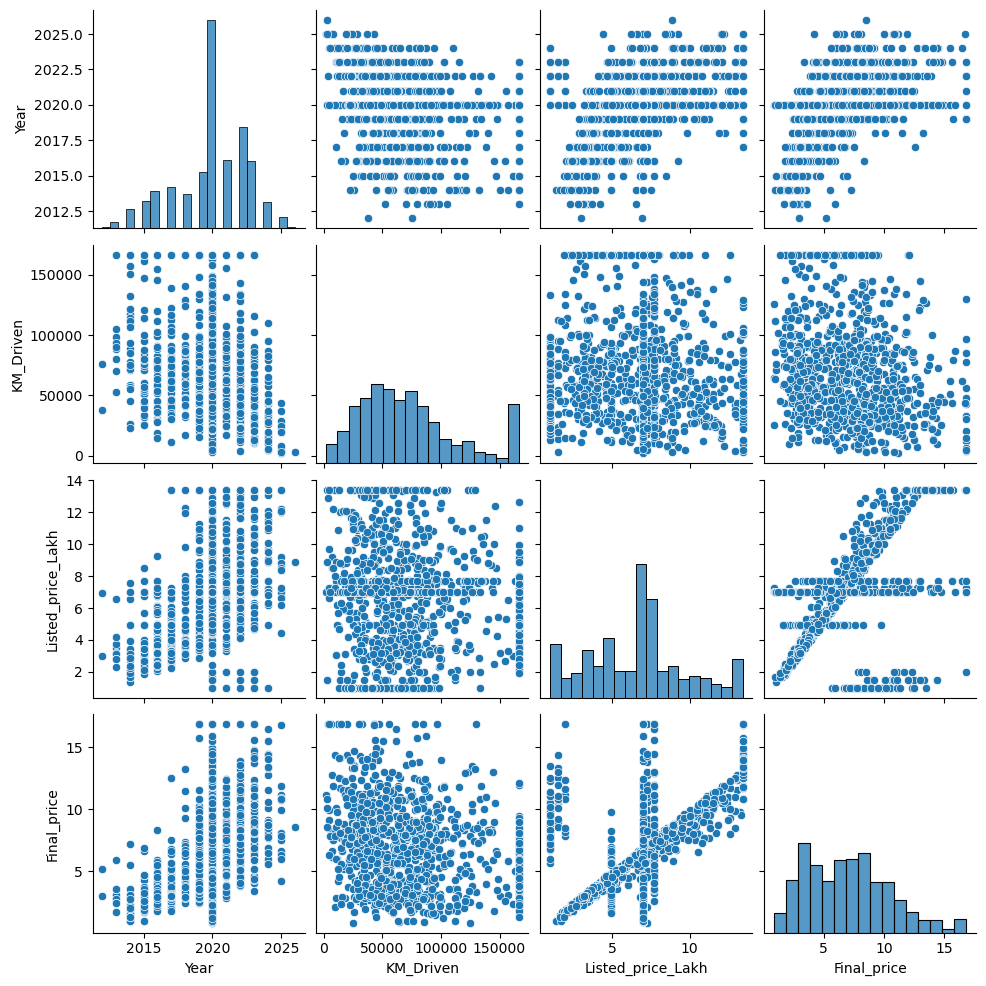

In [78]:
sns.pairplot(
    df[['Year',
        'KM_Driven',
        'Listed_price_Lakh',
        'Final_price']]
)

plt.show()

# Fuel vs Year vs Price

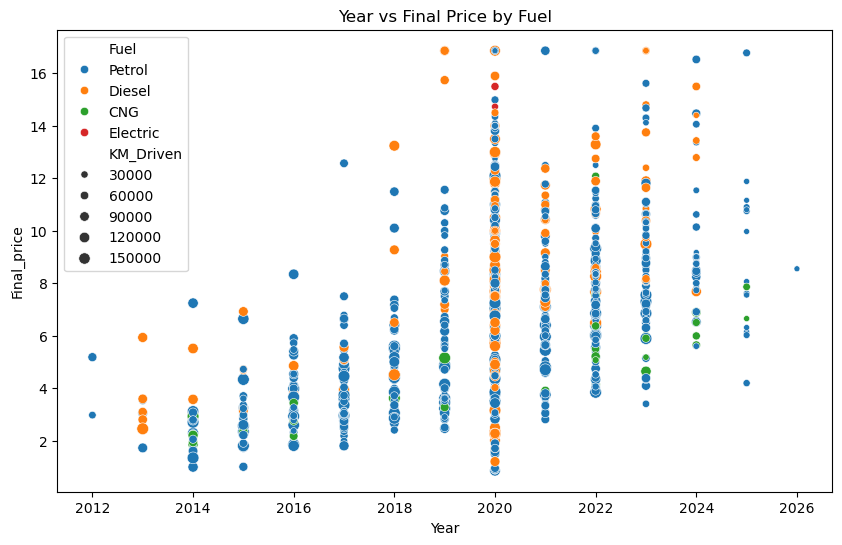

In [79]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Year',
    y='Final_price',
    hue='Fuel',
    size='KM_Driven'
)

plt.title("Year vs Final Price by Fuel")
plt.show()

# Brand vs Fuel vs Price

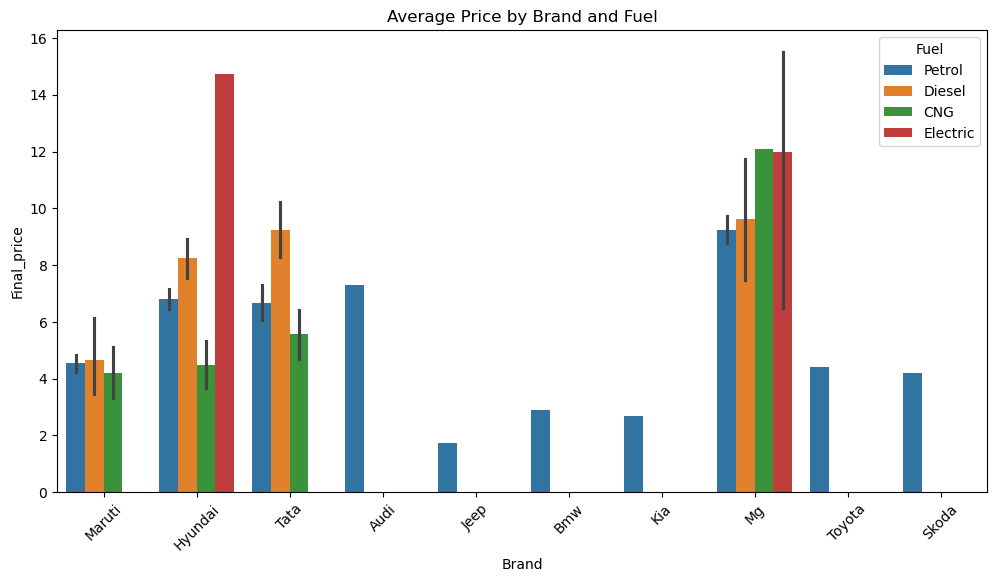

In [80]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='Brand',
    y='Final_price',
    hue='Fuel'
)

plt.xticks(rotation=45)
plt.title("Average Price by Brand and Fuel")
plt.show()

Observation:
Different brands show variations in average Final_price based on fuel type. Premium brands generally have higher prices, while fuel type creates differences in pricing within each brand.

Business Insight: 
Brand reputation and fuel preference significantly influence used car resale prices, helping businesses develop better pricing strategies.

# Year vs Transmission vs Price

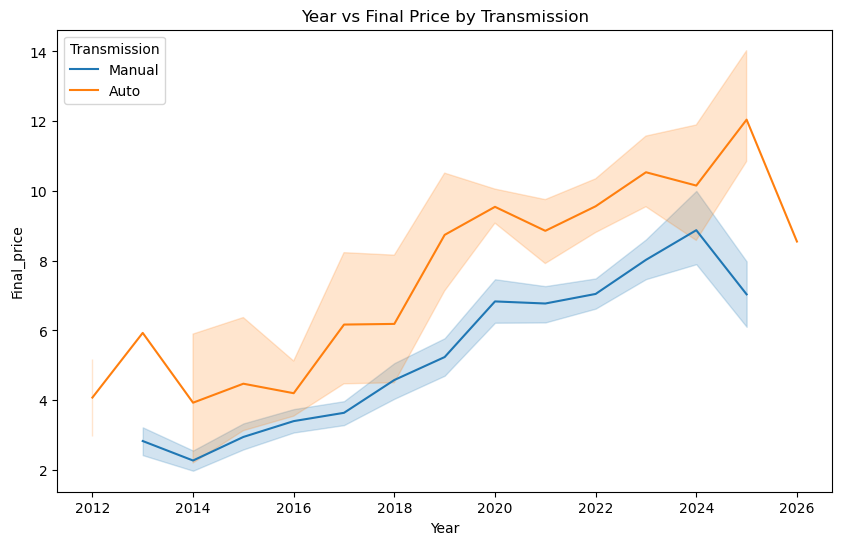

In [81]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x='Year',
    y='Final_price',
    hue='Transmission'
)

plt.title("Year vs Final Price by Transmission")
plt.show()

Observation:
Final_price generally increases for newer vehicles, and transmission type shows variation in price trends. Automatic cars tend to have higher resale prices compared to manual cars.

Business Insight: 
Vehicle age and transmission type are important factors affecting resale value, with newer automatic vehicles having stronger market demand.

# Business Analysis Graphs

# Top 10 Expensive Brands

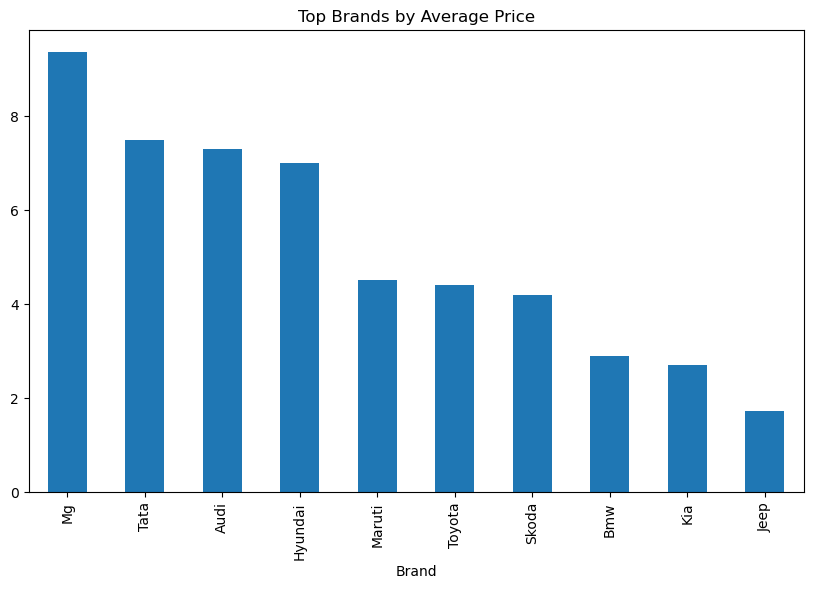

In [82]:
top = df.groupby('Brand')['Final_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
top.plot(kind='bar')
plt.title("Top Brands by Average Price")
plt.show()

# Location-wise Cars

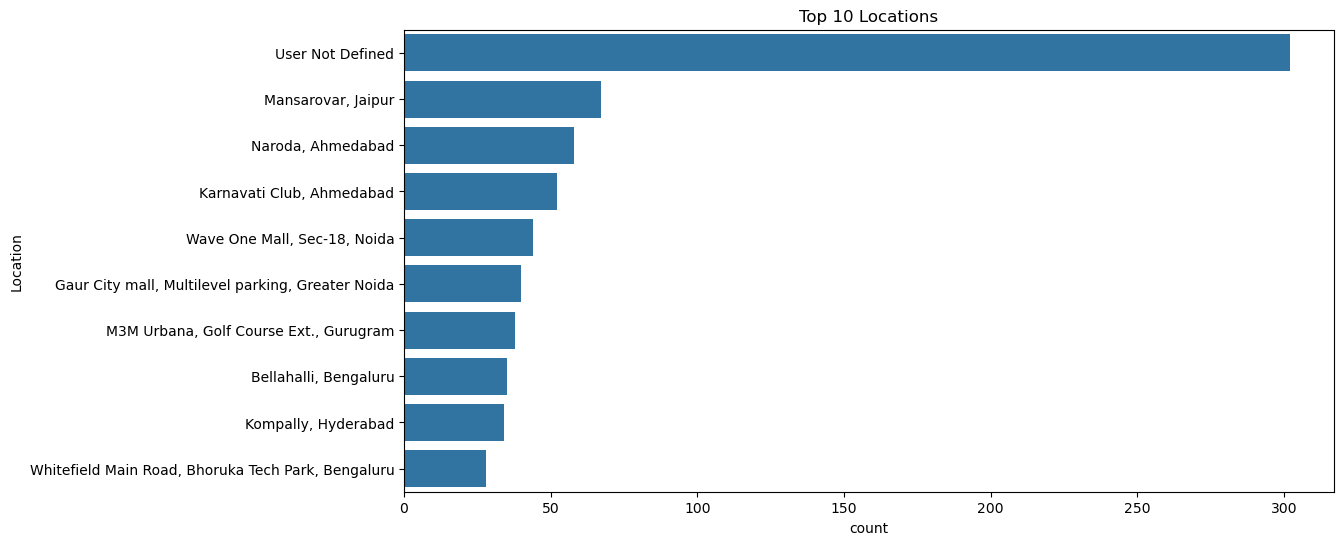

In [83]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Location',
    data=df,
    order=df['Location'].value_counts().head(10).index
)

plt.title("Top 10 Locations")
plt.show()

# Swarm Plot

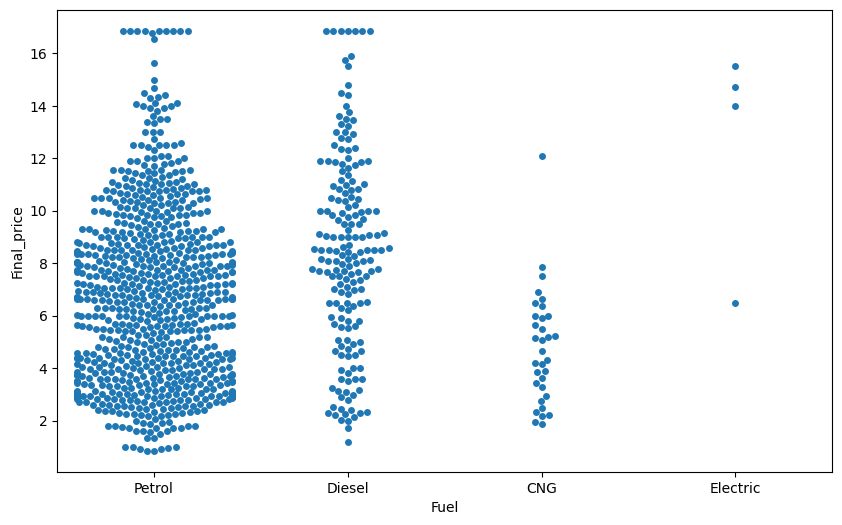

In [84]:
plt.figure(figsize=(10,6))

sns.swarmplot(
    x='Fuel',
    y='Final_price',
    data=df
)

plt.show()

# Strip Plot

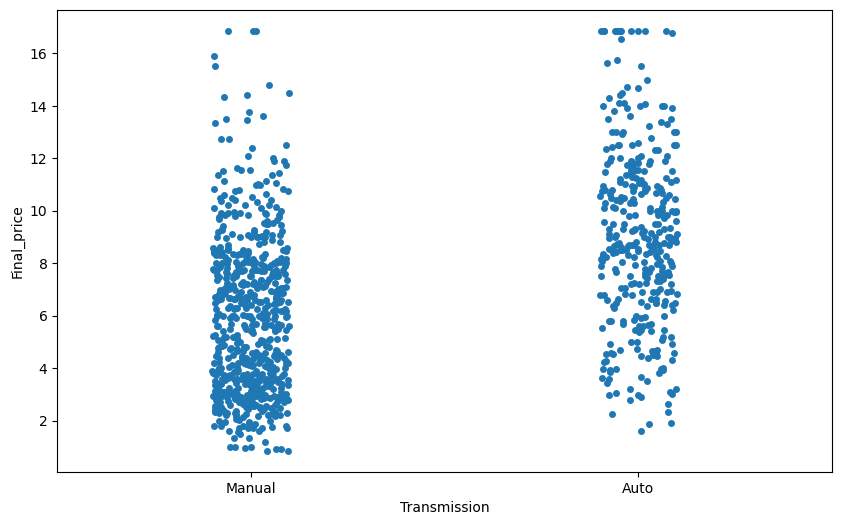

In [85]:
plt.figure(figsize=(10,6))

sns.stripplot(
    x='Transmission',
    y='Final_price',
    data=df,
    jitter=True
)

plt.show()

# Groupby Analysis
## Average Price by Brand

In [26]:
df.groupby('Brand')['Final_price'].mean()

Brand
BMW        2.890000
Hyundai    7.019793
Jeep       1.720000
MG         9.409350
Maruti     4.514875
Tata       7.510516
Toyota     4.400000
audi       7.300000
hyundai    4.750000
kia        2.700000
maruti     5.490000
mg         2.250000
skoda      4.190000
tata       3.250000
Name: Final_price, dtype: float64

In [ ]:
Observation:
MG has the highest average Final_price (9.40 lakh), followed by Tata (7.51 lakh), Audi (7.30 lakh), and Hyundai (7.01 lakh), while some brands have lower average prices.

Business Insight:
Brand value significantly affects resale pricing; premium brands maintain higher average prices, whereas budget brands are available at more affordable price ranges.

# Conclusion:
## Car price is mainly influenced by brand, manufacturing year, fuel type, transmission, and kilometers driven.
## Newer cars have higher resale value compared to older vehicles.
## Cars with lower KM_Driven maintain better prices.
## Premium brands have higher average selling prices.
## Automatic transmission vehicles generally have higher prices than manual vehicles.
## Certain locations have higher used car availability, indicating stronger markets.